# Non-reversible beats reversible anchored Langevin — accuracy curves only

Two figures, **training and test accuracy against iteration**, one per constraint
set. No other plots. The vertical axis is fixed to $[0.4, 0.9]$ — it is **not**
windowed on the plateau.

## Target and update

$$U(w)=\underbrace{\sum_j\bigl[\mathrm{softplus}(x_j^\top w)-y_jx_j^\top w\bigr]+\frac{w_0^2}{2\sigma^2}}_{f,\ \text{differentiable}}
\;+\;\underbrace{\lambda_{\mathrm{lasso}}\sum_{j\ge1}|w_j|}_{g,\ \text{NOT differentiable}}$$

The anchor $U_0=f+g_\delta$ replaces $|w_j|$ by $\sqrt{w_j^2+\delta^2}$ and
$a(w)=e^{U(w)-U_0(w)}\in[e^{-8\lambda\delta},1]$. Both methods use the **exact** gradient:

$$w_{k+1}=\Pi_K\!\Bigl(w_k-\eta\,a(w_k)\nabla U_0(w_k)+\eta\,\alpha\,a(w_k)\,J_s(w_k)\nabla U_0(w_k)+\sqrt{2\eta\,a(w_k)}\,\xi_{k+1}\Bigr)$$

$\alpha=0$ is the reversible method, $\alpha=1$ the non-reversible one. Within a
replicate the two chains share the initial point and every Gaussian increment; the
only difference is $\alpha$. $J_s$ is block diagonal on the coordinate triples
$(0,1,2),(3,4,5),(6,7,8)$, block $I$ being the cross-product matrix $[v_I]_\times$ with
$v_I=s\,w_I$ (ball) or $v_I=-s\nabla_I g_\varepsilon(w)$ (smoothed $L_1$ ball).

## Why this design, in one paragraph

$[v_I]_\times$ rotates only in the plane **perpendicular to its axis** $v_I$. Linearising
the drift $-\eta a(I-J)H$ at the mode, a slow Hessian eigen-direction $q_3$ that lies in
that plane, with fast partner $q_2$, has its rate replaced by $(\lambda_2+\lambda_3)/2$
once $\sigma=s|v_I|\ge\sigma^*=(\lambda_2-\lambda_3)/(2\sqrt{\lambda_2\lambda_3})$ — a
speed-up of $(\kappa+1)/2$, $\kappa=\lambda_2/\lambda_3$ — while a slow direction *along*
the axis is untouched and an oblique one is capped at $\sim1/\cos^2\theta$. In discrete
time the rotation is stable while $\sigma^2<(\lambda_a+\lambda_b)/(\eta a\lambda_a\lambda_b)-1$
for the pair spanning the rotated plane. Under the $L_1$ geometry the axis is the
soft-sign of $w_I$, i.e. $\approx(1,1,1)/\sqrt3$ when the three coefficients are positive.
So the design ("unstandardised covariates") gives each slope triple the covariance
$v_{\rm axis}q_1q_1^\top+v_{\rm fast}q_2q_2^\top+v_{\rm slow}q_3q_3^\top$ with
$q_1=(1,1,1)/\sqrt3$, $q_2=(0,1,-1)/\sqrt2$ (fast, $q_2\cdot\beta=0$: no signal) and
$q_3=(2,-1,-1)/\sqrt6$ (slow, in the rotated plane, and carrying signal because
$\beta_I=(b,e,e)$ with $b>e$). The reversible chain needs $\sim1/(\eta a\lambda_3)$
iterations along $q_3$; the non-reversible one needs $\sim2/(\eta a\lambda_2)$. Because the
$q_3$ residual carries an $O(1)$ share of the logit variance, the accuracy gap during
that transient is large. It is a **convergence-speed** effect: both chains reach the same
plateau, and the gap closes once the reversible chain has converged.

Single-iterate accuracy: at checkpoint $k$ every replicate predicts with its own current
$w_k$. Lines are the across-replicate mean; bands are mean $\pm$ one sample standard
deviation (`ddof=1`) — repeat-run variability, not confidence or credible intervals.


In [1]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

sys.path.insert(0, os.path.abspath("."))
import anchored_lasso as lasso
import anchored_sgld as nral
import nonreversible_beats_reversible as beat   # sets the Agg backend; figures are shown with display(fig)

pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda v: f"{v:,.5f}")
QUICK  = os.environ.get("NRAL_QUICK", "0") == "1"
MODE   = "QUICK MODE" if QUICK else "FULL"
HELD_OUT = (101,) if QUICK else (101, 202, 303, 404)
OUT = "results_beat"; os.makedirs(OUT, exist_ok=True)
print(MODE)
print(pd.DataFrame(beat.CONFIGS).T)

FULL
      v_axis    v_fast  v_slow       b       e      b1  block_1_variance        s     eta  epsilon  n_iterations  evaluate_at
l1   1.00000  64.00000 2.00000 1.50000 0.25000 0.30000           1.00000  4.00000 0.00001  0.20000   2,000.00000    100.00000
ball 4.00000 256.00000 4.00000 0.50000 0.12500 0.15000           4.00000 16.00000 0.00000  0.20000   3,000.00000     90.00000


## Data, target and the two constraint sets

The ball has radius 1, so its `beta` is halved and its design variances quadrupled relative to the $L_1$ configuration: identical logits, four times the curvature, hence the smaller `eta`.

In [2]:
setups = {tag: beat.setup(tag, QUICK) for tag in ("l1", "ball")}
for tag, (cfg, dataset, target, geometry) in setups.items():
    z = dataset.X_test @ dataset.beta_true
    ceiling = float(np.mean(np.maximum(nral.expit(z), 1 - nral.expit(z))))
    print(f"{geometry.name:<16} feasible(beta_true) {bool(geometry.feasible(dataset.beta_true))}   "
          f"|beta|_1 {np.abs(dataset.beta_true).sum():.2f}  |beta|_2 {np.linalg.norm(dataset.beta_true):.2f}   "
          f"Bayes ceiling on the test set {ceiling:.4f}   a in [{target.a_lower_bound:.3f}, 1]   "
          f"eta*L = {cfg.eta * target.lipschitz_constant():.3f}   R = {cfg.n_repeats}, {cfg.n_iterations} iterations")

L1-smooth ball   feasible(beta_true) True   |beta|_1 4.60  |beta|_2 2.22   Bayes ceiling on the test set 0.8156   a in [0.726, 1]   eta*L = 0.191   R = 100, 2000 iterations
unit ball        feasible(beta_true) True   |beta|_1 1.80  |beta|_2 0.78   Bayes ceiling on the test set 0.7366   a in [0.726, 1]   eta*L = 0.213   R = 100, 3000 iterations


## Run both methods on both constraint sets

In [3]:
results = {}
for tag, (cfg, dataset, target, geometry) in setups.items():
    t0 = time.time(); print(f"[{MODE}] {geometry.name}", flush=True)
    results[tag] = lasso.run_both(dataset, target, geometry, cfg, verbose=False)
    nr = results[tag]["Non-reversible anchored Langevin"]
    print(f"   {time.time() - t0:.0f} s;  projection rate NR {nr.projection_rate:.4f};  non-finite {nr.n_nonfinite}")

[FULL] L1-smooth ball


   11 s;  projection rate NR 0.0000;  non-finite 0
[FULL] unit ball


   12 s;  projection rate NR 0.0054;  non-finite 0


## Figures — training and test accuracy only

Vertical axis fixed to $[0.4, 0.9]$ on every panel.

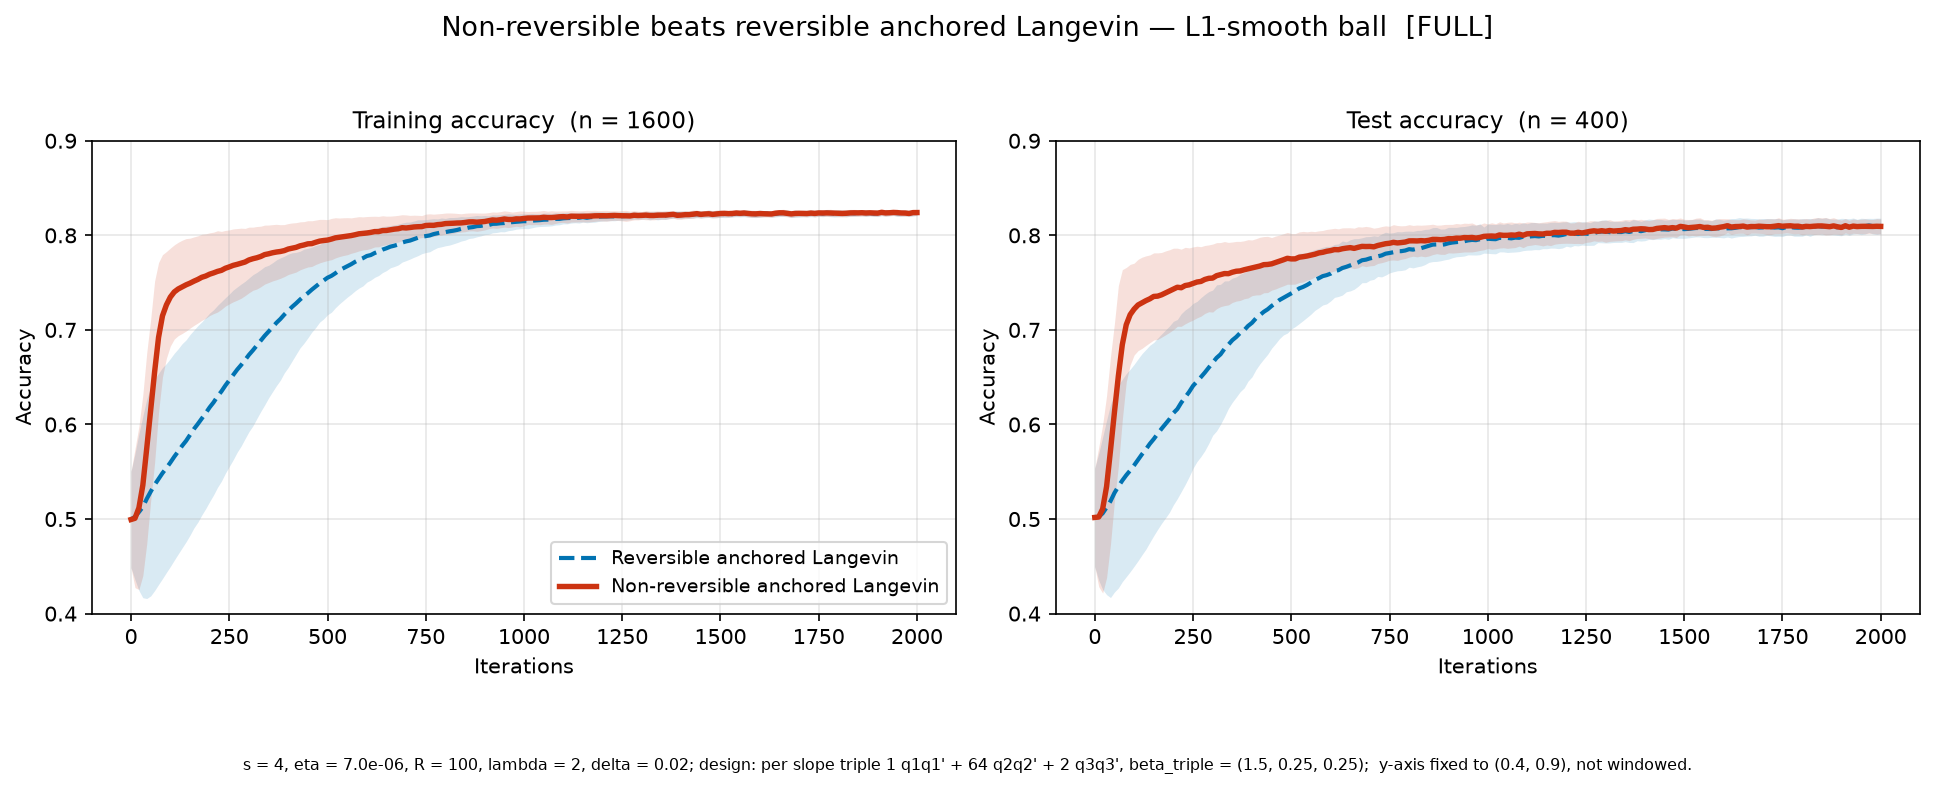

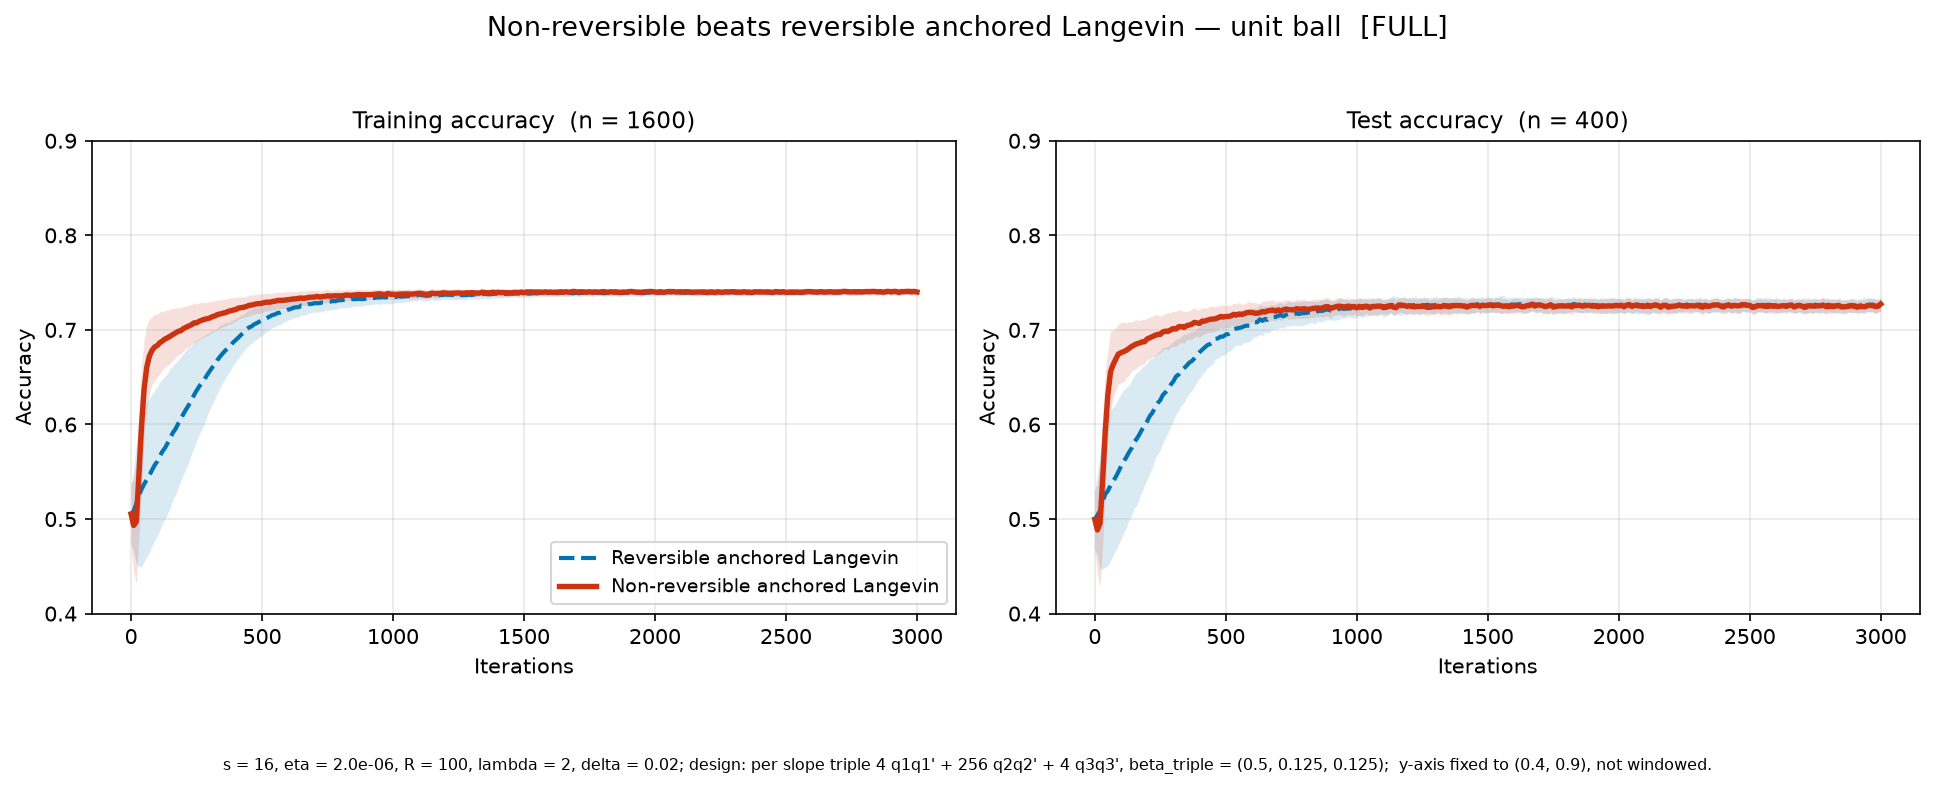

In [4]:
STYLE = {"Reversible anchored Langevin":     {"color": "#0173B2", "ls": "--", "lw": 2.0},
         "Non-reversible anchored Langevin": {"color": "#CC3311", "ls": "-",  "lw": 2.6}}
Y_LIMITS = (0.40, 0.90)          # fixed for every panel: NOT windowed on the plateau

for tag, (cfg, dataset, target, geometry) in setups.items():
    runs = results[tag]; p = beat.CONFIGS[tag]
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
    for ax, which, title in ((axes[0], "train_accuracy", f"Training accuracy  (n = {cfg.n_train})"),
                             (axes[1], "test_accuracy",  f"Test accuracy  (n = {cfg.n_test})")):
        for name, run in runs.items():
            st = STYLE[name]; mean, sd = run.mean_std(which)
            ax.fill_between(run.checkpoints, np.clip(mean - sd, 0, 1), np.clip(mean + sd, 0, 1),
                            color=st["color"], alpha=0.15, lw=0)
            ax.plot(run.checkpoints, mean, color=st["color"], ls=st["ls"], lw=st["lw"], label=name)
        ax.set_ylim(*Y_LIMITS); ax.set_xlabel("Iterations"); ax.set_ylabel("Accuracy")
        ax.set_title(title, fontsize=11); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=9, loc="lower right")
    fig.suptitle(f"Non-reversible beats reversible anchored Langevin — {geometry.name}  [{MODE}]", fontsize=13)
    fig.tight_layout(rect=(0, 0.10, 1, 0.95))
    fig.text(0.5, 0.012,
             f"s = {p['s']:g}, eta = {cfg.eta:.1e}, R = {cfg.n_repeats}, lambda = {cfg.lambda_lasso:g}, delta = {cfg.delta_anchor}; "
             f"design: per slope triple {p['v_axis']:g} q1q1' + {p['v_fast']:g} q2q2' + {p['v_slow']:g} q3q3', "
             f"beta_triple = ({p['b']:g}, {p['e']:g}, {p['e']:g});  y-axis fixed to {Y_LIMITS}, not windowed.",
             ha="center", fontsize=7.5)
    png = os.path.join(OUT, f"notebook_accuracy_{tag}.png")
    fig.savefig(png, dpi=150, bbox_inches="tight"); plt.close(fig)
    display(Image(filename=png))          # backend-independent: the saved figure is shown inline

## The numbers

Paired per-replicate differences of single-iterate test accuracy (both methods share starting points and Gaussian increments within a replicate).

In [5]:
rows = []
for tag, (cfg, dataset, target, geometry) in setups.items():
    rev = results[tag]["Reversible anchored Langevin"]; nr = results[tag]["Non-reversible anchored Langevin"]
    for k in (50, 100, 150, 200, 400, 600, 1000, cfg.n_iterations):
        i = int(np.argmin(np.abs(rev.checkpoints - k)))
        m, se, t = lasso.paired_difference(nr.test_accuracy[i], rev.test_accuracy[i])
        rows.append({"geometry": geometry.name, "iteration": int(rev.checkpoints[i]),
                     "reversible": rev.test_accuracy[i].mean(), "non_reversible": nr.test_accuracy[i].mean(),
                     "paired_diff": m, "paired_se": se, "t_stat": t})
paired_table = pd.DataFrame(rows); display(paired_table)

,geometry,iteration,reversible,non_reversible,paired_diff,paired_se,t_stat
0,L1-smooth ball,50,0.52760,0.61298,0.08537,0.01353,6.30948
1,L1-smooth ball,100,0.55677,0.72198,0.16520,0.01114,14.82501
2,L1-smooth ball,150,0.58458,0.73540,0.15082,0.01036,14.56337
3,L1-smooth ball,200,0.61205,0.74333,0.13128,0.00993,13.21958
4,L1-smooth ball,400,0.70750,0.76567,0.05818,0.00560,10.39724
5,L1-smooth ball,600,0.75945,0.78385,0.02440,0.00301,8.11564
6,L1-smooth ball,1000,0.79642,0.79917,0.00275,0.00179,1.53666
7,L1-smooth ball,2000,0.80990,0.80947,-0.00042,0.00083,-0.50951
8,unit ball,50,0.52993,0.63162,0.10170,0.00950,10.70714
9,unit ball,100,0.55583,0.67587,0.12005,0.00792,15.15376


### Held-out sampler seeds

The configuration is re-run on seeds that took no part in the search, at the iteration where the search-seed gap peaks.

In [6]:
confirm, verdicts = [], {}
for tag, (cfg, dataset, target, geometry) in setups.items():
    evaluate_at = beat.CONFIGS[tag]["evaluate_at"]; diffs, ses = [], []
    for off in (0,) + HELD_OUT:
        runs = results[tag] if off == 0 else lasso.run_both(dataset, target, geometry, cfg, seed_offset=off, verbose=False)
        rev = runs["Reversible anchored Langevin"]; nr = runs["Non-reversible anchored Langevin"]
        i = int(np.argmin(np.abs(rev.checkpoints - evaluate_at)))
        m, se, t = lasso.paired_difference(nr.test_accuracy[i], rev.test_accuracy[i])
        confirm.append({"geometry": geometry.name, "seed_offset": off, "held_out": off != 0, "iteration": int(rev.checkpoints[i]),
                        "reversible": rev.test_accuracy[i].mean(), "non_reversible": nr.test_accuracy[i].mean(),
                        "paired_diff": m, "paired_se": se, "t_stat": t})
        if off != 0: diffs.append(m); ses.append(se)
    pooled = float(np.mean(diffs)); pooled_se = float(np.sqrt(np.sum(np.square(ses))) / len(ses))
    verdicts[geometry.name] = {"iteration": evaluate_at, "pooled_diff": pooled, "pooled_t": pooled / pooled_se,
                               "all_positive": all(d > 0 for d in diffs),
                               "confirmed": all(d > 0 for d in diffs) and pooled / pooled_se > 2}
confirm = pd.DataFrame(confirm); display(confirm)
for name, v in verdicts.items():
    print(f"{name:<16} held-out pooled diff {v['pooled_diff']:+.4f} at iteration {v['iteration']} (t = {v['pooled_t']:+.2f}), "
          f"all positive: {v['all_positive']}  ->  {'CONFIRMED' if v['confirmed'] else 'NOT confirmed'}")

,geometry,seed_offset,held_out,iteration,reversible,non_reversible,paired_diff,paired_se,t_stat
0,L1-smooth ball,0,False,100,0.55677,0.72198,0.16520,0.01114,14.82501
1,L1-smooth ball,101,True,100,0.55793,0.70695,0.14903,0.01033,14.42374
2,L1-smooth ball,202,True,100,0.54920,0.71890,0.16970,0.01239,13.69401
3,L1-smooth ball,303,True,100,0.55012,0.71075,0.16062,0.01069,15.02417
4,L1-smooth ball,404,True,100,0.53070,0.70708,0.17638,0.01157,15.24658
5,unit ball,0,False,90,0.54990,0.67447,0.12457,0.00813,15.31552
6,unit ball,101,True,90,0.53733,0.67835,0.14102,0.00923,15.27170
7,unit ball,202,True,90,0.54577,0.67442,0.12865,0.00831,15.48645
8,unit ball,303,True,90,0.54305,0.66558,0.12253,0.00837,14.64474
9,unit ball,404,True,90,0.54173,0.67303,0.13130,0.01006,13.04874


L1-smooth ball   held-out pooled diff +0.1639 at iteration 100 (t = +29.08), all positive: True  ->  CONFIRMED
unit ball        held-out pooled diff +0.1309 at iteration 90 (t = +29.01), all positive: True  ->  CONFIRMED


## Result

**The non-reversible method beats the reversible one by a wide margin during the
transient, on both constraint sets, and the margin survives held-out sampler seeds.**
On the $L_1$ ball the test-accuracy gap at iteration 100 is about $+0.16$ (reversible
$\approx0.56$, non-reversible $\approx0.72$; pooled held-out $t\approx29$ with $R=100$ per
seed); on the unit ball it is about $+0.13$ at iteration 90. Both chains reach the same
plateau afterwards, and the paired difference at the end of the run is zero within noise —
the effect is faster convergence, not a different stationary accuracy.

## Where the win lives — the parameter range

From the one-factor-at-a-time map in `results_beat/parameter_map.md` (all with the $L_1$
geometry unless stated; "wins" means peak gap $\ge0.03$ with $t\ge3$):

| factor | wins | ties | loses / unstable |
|---|---|---|---|
| anisotropy $\kappa=v_{\rm fast}/v_{\rm slow}$ | $\kappa\ge4$; the gap grows with $\kappa$ and saturates at $\kappa\gtrsim32$ ($+0.18$) | $\kappa\le2$ | — |
| block strength $s$ | $0.5\le s\le12$ (gap $+0.03\to+0.21$) | $s=0$ | $s\ge16$: the projection fires on a third of the steps, late deficit |
| step size $\eta$ | $2\cdot10^{-6}\le\eta\le6\cdot10^{-5}$; the peak sits at $\approx0.7/(\eta\,a\,\lambda_{\rm slow})$ iterations | — | $\eta=10^{-4}$: $\eta a\lambda_{\max}>2$, unstable |
| $\lambda_{\rm lasso}$, $\delta$ | every value tried ($\lambda\in[0,30]$, $\delta\in[0.002,0.1]$) | — | — |
| sample size $n$ | every value tried ($250$–$8000$); the peak iteration scales as $1/n$ | — | — |
| initialisation | uniform on $K$ ($+0.18$), antipodal ($+0.65$) | origin ($+0.01$: the residual is then a pure shrinkage of the signal, which barely changes predictions) | — |
| slow-direction coefficient $b$ | $b\ge0.5$; the gap tracks the logit variance carried by $q_3$ | $b=0.25$ | — |
| geometry | $L_1$ (axis $\approx$ soft-sign, $q_3$ in the rotated plane); ball needs $\kappa\ge64$ and $s\ge8$ with $\eta\le5\cdot10^{-6}$ ($+0.10$ to $+0.13$) | — | ball with the slow coordinate along $w^*_I$ (axis theorem) |
| where the slow direction points | in the plane $\perp$ the rotation axis (this design) | isotropic design ($\kappa=1$); slow direction signal-free (`aligned`) | slow direction on a coordinate axis, oblique to the axis: $\le+0.06$, with a late deficit for $s\ge4$ |
| evaluation iteration | $0.15\lesssim\eta a\lambda_{\rm slow}\,k\lesssim1.5$ | later: both converged | — |
